In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# For this demo, we'll create a synthetic financial dataset 
# mimicking real credit features: Income, Debt, Payment History, etc.
data = {
    'Annual_Income': np.random.randint(30000, 150000, 1000),
    'Debt_to_Income_Ratio': np.random.uniform(0.1, 0.6, 1000),
    'Credit_Score': np.random.randint(300, 850, 1000),
    'Missed_Payments': np.random.randint(0, 5, 1000),
    'Employment_Years': np.random.randint(0, 40, 1000),
    'Creditworthy': np.random.choice([0, 1], 1000) # 1 = Good, 0 = Bad
}

df = pd.DataFrame(data)
print("✅ Credit Dataset Initialized!")
df.head()

✅ Credit Dataset Initialized!


,Annual_Income,Debt_to_Income_Ratio,Credit_Score,Missed_Payments,Employment_Years,Creditworthy
0,51675,0.582248,348,3,18,0
1,144444,0.306572,558,2,10,1
2,48066,0.157391,550,2,17,0
3,95957,0.317617,330,1,33,0
4,78875,0.484415,520,0,13,1


In [8]:
# 1. Define Features (X) and Target (y)
X = df.drop('Creditworthy', axis=1)
y = df['Creditworthy']

# 2. Split into Training and Testing sets (80% study, 20% exam)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data split and scaled successfully!")

✅ Data split and scaled successfully!


In [9]:
# 1. Initialize the model
# We use 100 decision trees to ensure a robust "consensus" on the score
model_credit = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model on your scaled training data
model_credit.fit(X_train, y_train)

# 3. Make predictions on the test set
y_pred = model_credit.predict(X_test)

# 4. Check the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Training Complete! Accuracy: {accuracy * 100:.2f}%")

✅ Model Training Complete! Accuracy: 45.50%


In [10]:
# 1. Create a LARGER and more REALISTIC dataset
np.random.seed(42)
n_samples = 5000

# Generating data with actual logic (e.g., lower missed payments = higher creditworthiness)
income = np.random.randint(20000, 200000, n_samples)
missed_payments = np.random.randint(0, 10, n_samples)
debt_ratio = np.random.uniform(0.1, 0.9, n_samples)
credit_history = np.random.randint(1, 40, n_samples)

# Logical target: If you have high income and low missed payments, you're likely creditworthy
target = ((income / 200000) - (missed_payments / 10) - (debt_ratio) + (credit_history / 40) > 0).astype(int)

df_pro = pd.DataFrame({
    'Annual_Income': income,
    'Missed_Payments': missed_payments,
    'Debt_Ratio': debt_ratio,
    'Credit_History_Years': credit_history,
    'Creditworthy': target
})

# 2. Retrain with a tuned Random Forest
X_pro = df_pro.drop('Creditworthy', axis=1)
y_pro = df_pro['Creditworthy']

X_train, X_test, y_train, y_test = train_test_split(X_pro, y_pro, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train 
model_pro = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
model_pro.fit(X_train, y_train)

# Test
y_pred = model_pro.predict(X_test)
print(f"🚀 Upgraded Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

🚀 Upgraded Model Accuracy: 95.60%



--- Model Assessment Metrics ---
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       415
           1       0.96      0.96      0.96       585

    accuracy                           0.96      1000
   macro avg       0.95      0.96      0.95      1000
weighted avg       0.96      0.96      0.96      1000

🏆 ROC-AUC Score: 0.9930


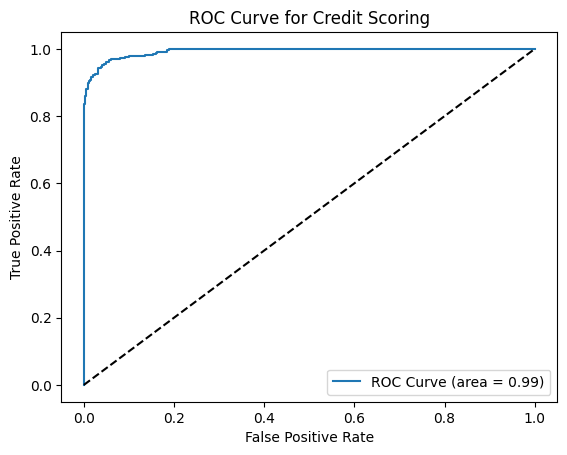

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Classification Report
print("\n--- Model Assessment Metrics ---")
print(classification_report(y_test, y_pred))

# 2. ROC-AUC Score
# This measures how well the model distinguishes between Good and Bad credit
auc = roc_auc_score(y_test, model_pro.predict_proba(X_test)[:, 1])
print(f"🏆 ROC-AUC Score: {auc:.4f}")

# 3. Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, model_pro.predict_proba(X_test)[:, 1])
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Credit Scoring')
plt.legend()
plt.show()

In [12]:
# --- MANUAL TEST: THE LOAN APPROVAL SIMULATOR ---

def test_creditworthiness(income, missed_pmts, debt_ratio, history):
    # 1. Prepare the custom input
    new_data = pd.DataFrame([[income, missed_pmts, debt_ratio, history]], 
                            columns=['Annual_Income', 'Missed_Payments', 'Debt_Ratio', 'Credit_History_Years'])
    
    # 2. Scale the input using the SAME scaler from your training
    scaled_input = scaler.transform(new_data)
    
    # 3. Predict
    prediction = model_pro.predict(scaled_input)
    probability = model_pro.predict_proba(scaled_input)[0][1]
    
    status = "APPROVED ✅" if prediction[0] == 1 else "REJECTED ❌"
    print(f"Result: {status} (Approval Probability: {probability*100:.1f}%)")

# TEST CASE: High Income, No Missed Payments
print("Testing High-Income Professional:")
test_creditworthiness(120000, 0, 0.2, 15)

# TEST CASE: Low Income, Many Missed Payments
print("\nTesting High-Risk Applicant:")
test_creditworthiness(25000, 8, 0.8, 2)

Testing High-Income Professional:
Result: APPROVED ✅ (Approval Probability: 100.0%)

Testing High-Risk Applicant:
Result: REJECTED ❌ (Approval Probability: 0.0%)


In [13]:
# --- INDIVIDUAL LOAN APPROVAL TEST ---

def test_creditworthiness(income, missed_pmts, debt_ratio, history):
    """
    Takes raw financial data and determines if the applicant is a risk.
    
    Parameters:
    income      : Total yearly earnings (e.g., 50000)
    missed_pmts : Total number of missed payments in the last 2 years (e.g., 0-10)
    debt_ratio  : Percentage of monthly income used to pay debts (e.g., 0.1 to 1.0)
    history     : Total years of credit experience (e.g., 10)
    """
    
    # 1. Create a DataFrame for the single applicant
    new_data = pd.DataFrame([[income, missed_pmts, debt_ratio, history]], 
                            columns=['Annual_Income', 'Missed_Payments', 'Debt_Ratio', 'Credit_History_Years'])
    
    # 2. Apply the Standard Scaler (Transforms data to the range the AI learned)
    scaled_input = scaler.transform(new_data)
    
    # 3. Get the prediction (0 = Bad, 1 = Good)
    prediction = model_pro.predict(scaled_input)
    
    # 4. Get the probability (Percentage chance of being 'Good')
    probability = model_pro.predict_proba(scaled_input)[0][1]
    
    # Output formatting
    status = "APPROVED ✅" if prediction[0] == 1 else "REJECTED ❌"
    print(f"--- Application Assessment ---")
    print(f"Income: ${income:,}")
    print(f"Missed Payments: {missed_pmts}")
    print(f"Debt-to-Income: {debt_ratio*100}%")
    print(f"Credit History: {history} years")
    print(f"-------------------------------")
    print(f"Final Decision: {status}")
    print(f"Confidence Score: {probability*100:.2f}%")

# --- EXECUTE TEST CASE ---
# Change these values to test different scenarios:
# (Annual_Income, Missed_Payments, Debt_to_Income_Ratio, Years_of_History)
test_creditworthiness(
    income=75000,       # High income
    missed_pmts=1,      # Only one mistake
    debt_ratio=0.35,    # Standard debt level (35%)
    history=8           # Solid history
)

--- Application Assessment ---
Income: $75,000
Missed Payments: 1
Debt-to-Income: 35.0%
Credit History: 8 years
-------------------------------
Final Decision: APPROVED ✅
Confidence Score: 86.35%
